# Problem Statement

The goal of this project is to build:

1. A recommendation system that suggests top 5 relevant profiles for each user.
2. A classification model that predicts whether a matrimony request will be accepted.

The system uses:
- profile similarity
- demographic matching
- interest-based recommendation
- machine learning classification



In [ ]:
!pip install numpy pandas scikit-learn

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import (
    OneHotEncoder,
    MultiLabelBinarizer,
    MinMaxScaler
)

from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
#CREATE DATASET

data = {
    "user_id": [1,2,3,4,5,6,7,8,9,10],

    "age": [28,25,30,27,29,26,31,24,28,27],

    "gender": [
        "M","F","M","F","M",
        "F","M","F","M","F"
    ],

    "religion": [
        "Hindu","Hindu","Hindu","Hindu","Hindu",
        "Hindu","Hindu","Hindu","Hindu","Hindu"
    ],

    "caste": [
        "Maratha","Maratha","Brahmin","Maratha","Maratha",
        "Brahmin","Maratha","Maratha","Brahmin","Maratha"
    ],

    "city": [
        "Pune","Mumbai","Nashik","Pune","Pune",
        "Mumbai","Nashik","Pune","Mumbai","Nashik"
    ],

    "education": [
        "Engineer","Doctor","Engineer","Teacher","Business",
        "Engineer","Farmer","Designer","Engineer","Doctor"
    ],

    "income": [
        600000,800000,700000,400000,900000,
        650000,300000,500000,750000,850000
    ],

    "interests": [
        "cricket,music",
        "music,travel",
        "reading,music",
        "travel,cooking",
        "cricket,travel",
        "music,reading",
        "farming,travel",
        "art,music",
        "music,tech",
        "travel,reading"
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

print("Original Dataset:\n")
display(df)

# Convert string interests to list
df["interests"] = df["interests"].apply(
    lambda x: x.split(",")
)

# Convert interests into binary vectors
mlb = MultiLabelBinarizer()

interest_features = mlb.fit_transform(
    df["interests"]
)

interest_df = pd.DataFrame(
    interest_features,
    columns=mlb.classes_
)

print("\nInterest Features:\n")
display(interest_df)


categorical_cols = [
    "religion",
    "caste",
    "city",
    "education"
]

# sparse=False for old sklearn compatibility
encoder = OneHotEncoder(sparse_output=False)

encoded_features = encoder.fit_transform(
    df[categorical_cols]
)

encoded_df = pd.DataFrame(
    encoded_features,
    columns=encoder.get_feature_names_out(
        categorical_cols
    )
)

print("\nEncoded Categorical Features:\n")
display(encoded_df)


scaler = MinMaxScaler()

numeric_features = scaler.fit_transform(
    df[["age", "income"]]
)

numeric_df = pd.DataFrame(
    numeric_features,
    columns=["age", "income"]
)

print("\nScaled Numeric Features:\n")
display(numeric_df)


final_features = pd.concat(
    [
        numeric_df,
        encoded_df,
        interest_df
    ],
    axis=1
)

print("\nFinal Feature Matrix:\n")
display(final_features)

#CALCULATE COSINE SIMILARITY

similarity_matrix = cosine_similarity(
    final_features
)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=df["user_id"],
    columns=df["user_id"]
)

print("\nSimilarity Matrix:\n")
display(similarity_df)

#GENERATE RECOMMENDATIONS

recommendations = {}

for idx, user in df.iterrows():

    user_gender = user["gender"]

    # Select opposite gender users
    opposite_gender_indices = df[
        df["gender"] != user_gender
    ].index

    similarity_scores = []

    for other_idx in opposite_gender_indices:

        score = similarity_matrix[idx][other_idx]

        other_user_id = df.iloc[other_idx]["user_id"]

        similarity_scores.append(
            (other_user_id, score)
        )

    # Sort descending by similarity score
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Top 5 matches
    top_matches = [
        int(user_id)
        for user_id, score
        in similarity_scores[:5]
    ]

    recommendations[user["user_id"]] = top_matches

#PRINT FINAL MATCHES

print(" TOP 5 MATCH RECOMMENDATIONS ")


for user_id, matches in recommendations.items():

    print(f"User {user_id} -> {matches}")

Original Dataset:



,user_id,age,gender,religion,caste,city,education,income,interests
0,1,28,M,Hindu,Maratha,Pune,Engineer,600000,"cricket,music"
1,2,25,F,Hindu,Maratha,Mumbai,Doctor,800000,"music,travel"
2,3,30,M,Hindu,Brahmin,Nashik,Engineer,700000,"reading,music"
3,4,27,F,Hindu,Maratha,Pune,Teacher,400000,"travel,cooking"
4,5,29,M,Hindu,Maratha,Pune,Business,900000,"cricket,travel"
5,6,26,F,Hindu,Brahmin,Mumbai,Engineer,650000,"music,reading"
6,7,31,M,Hindu,Maratha,Nashik,Farmer,300000,"farming,travel"
7,8,24,F,Hindu,Maratha,Pune,Designer,500000,"art,music"
8,9,28,M,Hindu,Brahmin,Mumbai,Engineer,750000,"music,tech"
9,10,27,F,Hindu,Maratha,Nashik,Doctor,850000,"travel,reading"



Interest Features:



,art,cooking,cricket,farming,music,reading,tech,travel
0,0,0,1,0,1,0,0,0
1,0,0,0,0,1,0,0,1
2,0,0,0,0,1,1,0,0
3,0,1,0,0,0,0,0,1
4,0,0,1,0,0,0,0,1
5,0,0,0,0,1,1,0,0
6,0,0,0,1,0,0,0,1
7,1,0,0,0,1,0,0,0
8,0,0,0,0,1,0,1,0
9,0,0,0,0,0,1,0,1



Encoded Categorical Features:



...


Final Feature Matrix:



,age,income,religion_Hindu,caste_Brahmin,caste_Maratha,city_Mumbai,city_Nashik,city_Pune,education_Business,education_Designer,...,education_Farmer,education_Teacher,art,cooking,cricket,farming,music,reading,tech,travel
0,0.571429,0.500000,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0,0,1,0,1,0,0,0
1,0.142857,0.833333,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0,0,0,1,0,0,1
2,0.857143,0.666667,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0,0,0,0,1,1,0,0
3,0.428571,0.166667,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0,1,0,0,0,0,0,1
4,0.714286,1.000000,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0,0,1,0,0,0,0,1
5,0.285714,0.583333,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0,0,0,1,1,0,0
6,1.000000,0.000000,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0,0,0,1,0,0,0,1
7,0.000000,0.333333,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1,0,0,0,1,0,0,0
8,0.571429,0.750000,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0,0,0,1,0,1,0
9,0.428571,0.916667,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0,0,0,0,0,1,0,1



Similarity Matrix:



user_id,1,2,3,4,5,6,7,8,9,10
user_id,,,,,,,,,,
1,1.000000,0.526430,0.556397,0.520737,0.698385,0.531629,0.378989,0.657249,0.549926,0.397735
2,0.526430,1.000000,0.385706,0.495508,0.554169,0.537089,0.458413,0.511683,0.544982,0.702584
3,0.556397,0.385706,1.000000,0.221399,0.310360,0.829721,0.403039,0.335499,0.709525,0.560258
4,0.520737,0.495508,0.221399,1.000000,0.654871,0.193114,0.519957,0.495945,0.209417,0.505123
5,0.698385,0.554169,0.310360,0.654871,1.000000,0.257376,0.512272,0.492031,0.300040,0.581410
6,0.531629,0.537089,0.829721,0.193114,0.257376,1.000000,0.191762,0.350294,0.842047,0.395637
7,0.378989,0.458413,0.403039,0.519957,0.512272,0.191762,1.000000,0.305788,0.226291,0.631573
8,0.657249,0.511683,0.335499,0.495945,0.492031,0.350294,0.305788,1.000000,0.346771,0.351904
9,0.549926,0.544982,0.709525,0.209417,0.300040,0.842047,0.226291,0.346771,1.000000,0.277796


 TOP 5 MATCH RECOMMENDATIONS 
User 1 -> [8, 6, 2, 4, 10]
User 2 -> [5, 9, 1, 7, 3]
User 3 -> [6, 10, 2, 8, 4]
User 4 -> [5, 1, 7, 3, 9]
User 5 -> [4, 10, 2, 8, 6]
User 6 -> [9, 3, 1, 5, 7]
User 7 -> [10, 4, 2, 8, 6]
User 8 -> [1, 5, 9, 3, 7]
User 9 -> [6, 2, 8, 10, 4]
User 10 -> [7, 5, 3, 1, 9]


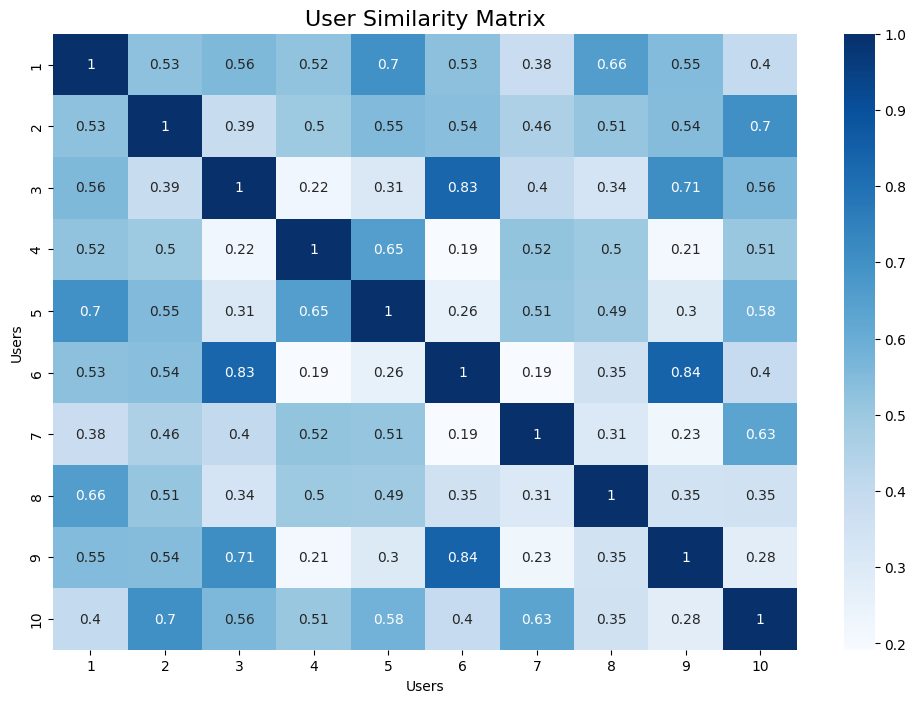

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    similarity_df,
    annot=True,
    cmap="Blues"
)

plt.title(
    "User Similarity Matrix",
    fontsize=16
)

plt.xlabel("Users")
plt.ylabel("Users")

plt.show()

# Recommendation Logic

The recommendation engine uses:
- age similarity
- city matching
- caste compatibility
- educational similarity
- common interests

Cosine similarity is used to calculate profile closeness.

# Assumptions

* Only opposite gender profiles are matched
* Equal feature importance is assumed
* Interests strongly influence recommendations
* Dataset contains no missing values

In [ ]:
recommendation_results = []

for idx, user in df.iterrows():

    user_gender = user["gender"]

    opposite_gender_indices = df[
        df["gender"] != user_gender
    ].index

    similarity_scores = []

    for other_idx in opposite_gender_indices:

        score = similarity_matrix[idx][other_idx]

        other_user_id = df.iloc[other_idx]["user_id"]

        similarity_scores.append(
            (other_user_id, score)
        )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    for match_id, score in similarity_scores[:5]:

        recommendation_results.append({
            "User": int(user["user_id"]),
            "Recommended_User": int(match_id),
            "Similarity_Score": round(score, 3)
        })

recommendation_df = pd.DataFrame(
    recommendation_results
)

display(recommendation_df)

,User,Recommended_User,Similarity_Score
0,1,8,0.657
1,1,6,0.532
2,1,2,0.526
3,1,4,0.521
4,1,10,0.398
5,2,5,0.554
6,2,9,0.545
7,2,1,0.526
8,2,7,0.458
9,2,3,0.386


# Matrimony Request Acceptance Prediction

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

from sklearn.preprocessing import MinMaxScaler

In [16]:
#CREATE DATASET

data = {
    "user_id": [1,2,3,4,5,6,7,8,9,10],

    "sender_age": [28,30,29,27,31,26,32,28,29,30],

    "receiver_age": [25,27,24,26,28,25,27,24,26,27],

    "same_city": [0,1,0,1,0,1,0,1,0,1],

    "same_caste": [1,1,0,1,1,0,1,1,0,1],

    "income_diff": [
        200000,
        100000,
        300000,
        50000,
        400000,
        150000,
        350000,
        200000,
        250000,
        100000
    ],

    "interest_sent": [1,1,1,1,1,1,1,1,1,1],

    "accepted": [1,1,0,1,0,1,0,1,0,1]
}

df = pd.DataFrame(data)

print("Original Dataset:\n")
display(df)

#DATA PREPROCESSING

# Check missing values
print("\nMissing Values:\n")
print(df.isnull().sum())

# Features and target
X = df.drop(
    columns=[
        "user_id",
        "accepted",
        "interest_sent"
    ]
)

y = df["accepted"]

#SCALE NUMERIC FEATURES


scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

print("\nScaled Features:\n")

scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

display(scaled_df)

#TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

#BUILD MODEL

model = LogisticRegression()

model.fit(X_train, y_train)

#PREDICTIONS

y_pred = model.predict(X_test)

print("\nPredictions:\n")
print(y_pred)

#MODEL EVALUATION

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

print(" MODEL PERFORMANCE ")

print(f"Accuracy  : {accuracy:.2f}")
print(f"Precision : {precision:.2f}")
print(f"Recall    : {recall:.2f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

# STEP 8: CUSTOM PREDICTION

# Example Input:
# sender_age=28
# receiver_age=25
# same_city=1
# same_caste=1
# income_diff=100000
# interest_sent=1

new_data = pd.DataFrame([[
    29,
    24,
    0,
    0,
    300000
]], columns=X.columns)

# Scale new input
new_data_scaled = scaler.transform(new_data)

# Predict
prediction = model.predict(new_data_scaled)

print(" CUSTOM PREDICTION ")

if prediction[0] == 1:
    print("Accepted = 1")
else:
    print("Accepted = 0")

Original Dataset:



,user_id,sender_age,receiver_age,same_city,same_caste,income_diff,interest_sent,accepted
0,1,28,25,0,1,200000,1,1
1,2,30,27,1,1,100000,1,1
2,3,29,24,0,0,300000,1,0
3,4,27,26,1,1,50000,1,1
4,5,31,28,0,1,400000,1,0
5,6,26,25,1,0,150000,1,1
6,7,32,27,0,1,350000,1,0
7,8,28,24,1,1,200000,1,1
8,9,29,26,0,0,250000,1,0
9,10,30,27,1,1,100000,1,1



Missing Values:

user_id          0
sender_age       0
receiver_age     0
same_city        0
same_caste       0
income_diff      0
interest_sent    0
accepted         0
dtype: int64

Scaled Features:



,sender_age,receiver_age,same_city,same_caste,income_diff
0,0.333333,0.25,0.0,1.0,0.428571
1,0.666667,0.75,1.0,1.0,0.142857
2,0.500000,0.00,0.0,0.0,0.714286
3,0.166667,0.50,1.0,1.0,0.000000
4,0.833333,1.00,0.0,1.0,1.000000
5,0.000000,0.25,1.0,0.0,0.285714
6,1.000000,0.75,0.0,1.0,0.857143
7,0.333333,0.00,1.0,1.0,0.428571
8,0.500000,0.50,0.0,0.0,0.571429
9,0.666667,0.75,1.0,1.0,0.142857



Training Data Shape: (8, 5)
Testing Data Shape: (2, 5)

Predictions:

[0 1]
 MODEL PERFORMANCE 
Accuracy  : 1.00
Precision : 1.00
Recall    : 1.00

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2


Confusion Matrix:

[[1 0]
 [0 1]]
 CUSTOM PREDICTION 
Accepted = 0


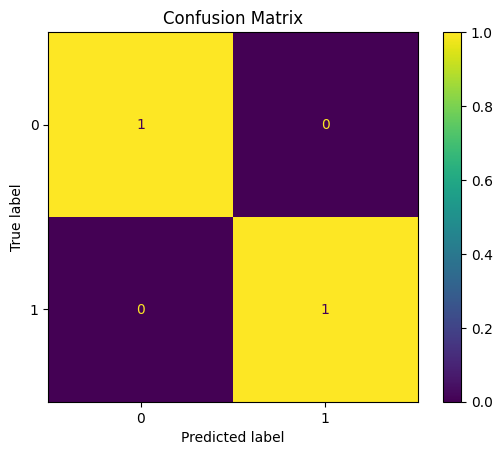

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test
)

plt.title("Confusion Matrix")

plt.show()

In [17]:
probabilities = model.predict_proba(
    new_data_scaled
)

print(
    "Acceptance Probability:",
    probabilities[0][1]
)

Acceptance Probability: 0.4754521909847339
